# Lead Time : 6 h

In [1]:
lead_time = 6

# Import Modules

In [30]:
import numpy as np
import pandas as pd 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve                  
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf                                                                 
from tensorflow.keras.initializers import he_normal                                      # type: ignore
from sklearn.model_selection import train_test_split         
from tensorflow.keras import regularizers                                                # type: ignore
from joblib import dump                                                           
from sklearn.preprocessing import StandardScaler                                        

# Import Data

In [3]:
train = pd.read_csv("../../../output/data/dakar/data-train-eps-dakar.csv")
test = pd.read_csv("../../../output/data/dakar/data-test-eps-dakar.csv")

In [4]:
train, validation = train_test_split(train, test_size=0.2, random_state=12)

# Selecting Header

In [5]:
def choose_header(n, location, lead_time):
    """
    Generate header names for n closest storms.

    Returns:
        tuple of two lists:
            - input headers: year, month, day, hour, minute, lat1..n, lon1..n, wp1..n, size1..n, d1..n, mask1..n
            - target header: Cb_{location}_t{lead_time}
    """
    input_headers = ['year', 'month', 'day', 'hour', 'minute']
    
    for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
        input_headers.extend([f'{prefix}{i}' for i in range(1, n + 1)])
    
    target_header = [f'Cb_{location}_t{lead_time}']
    
    return input_headers, target_header

In [6]:
input_headers, target_header = choose_header(3, "dakar", lead_time)

In [7]:
X_train = train[input_headers]
X_val = validation[input_headers]
X_test = test[input_headers]

y_train = train[target_header]
y_val = validation[target_header]
y_test = test[target_header]
y_persistence = test["Cb_dakar_t0"]

# Exploratory data analysis

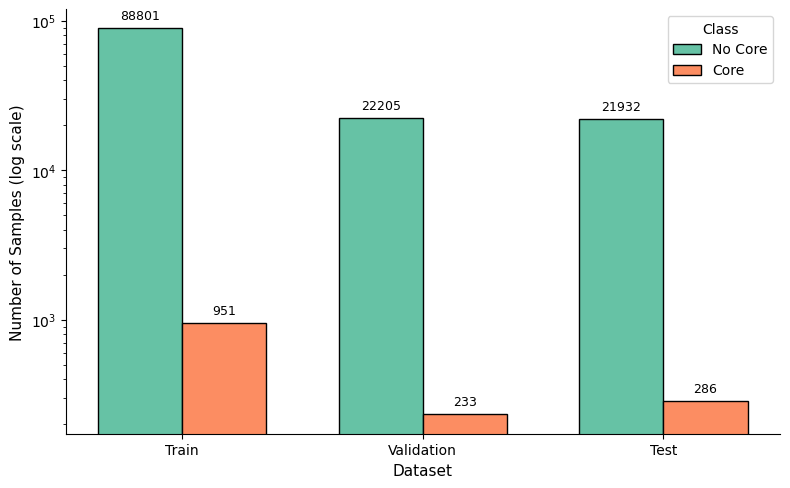

In [8]:
# Dataset types
types = ['Train', 'Validation', 'Test']

# Replace with your actual labels: 0 = No Core, 1 = Core
no_core = [y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]
core     = [y_train.value_counts()[1], y_val.value_counts()[1], y_test.value_counts()[1]]

x = np.arange(len(types))
width = 0.35

palette = sns.color_palette("Set2", 2)

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, no_core, width, label='No Core', color=palette[0], edgecolor='black')
bars2 = ax.bar(x + width/2, core, width, label='Core', color=palette[1], edgecolor='black')

# Annotate bars with counts
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height * 1.1, f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)

# Log scale for better visibility of small core counts
ax.set_yscale('log')
ax.set_ylabel("Number of Samples (log scale)", fontsize=11)
ax.set_xlabel("Dataset", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.legend(title="Class")
sns.despine()
plt.tight_layout()
plt.show()

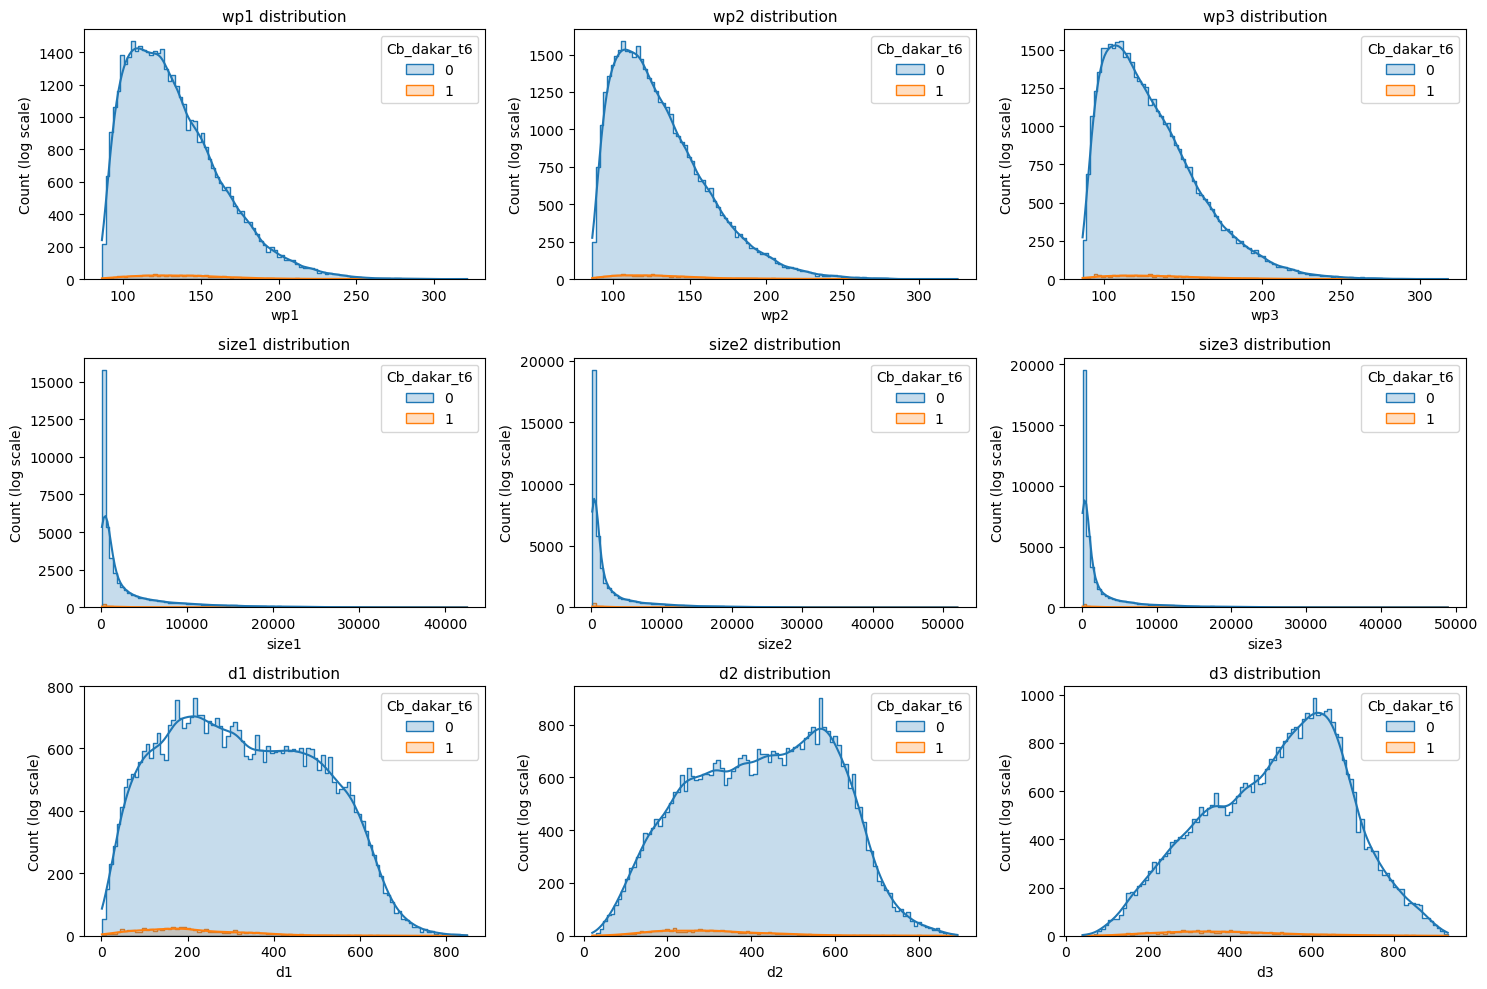

In [9]:
df = train

# Only include rows with at least one valid storm
real_mask = (df['mask1'] == 1) & (df['mask2'] == 1) & (df['mask3'] == 1)

features = ['wp', 'size', 'd']
storm_indices = [1, 2, 3]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for row_idx, feature in enumerate(features):
    for col_idx, storm_idx in enumerate(storm_indices):
        ax = axes[row_idx, col_idx]
        feature_name = f'{feature}{storm_idx}'
        
        # Plot histogram
        sns.histplot(
            data=df[real_mask],
            x=feature_name,
            hue=f'Cb_dakar_t{lead_time}',
            kde=True,
            common_norm=False,
            ax=ax,
            element="step",
            bins= 100
        )

        # Apply log scale
        #ax.set_yscale('log')
        ax.set_title(f'{feature_name} distribution', fontsize=11)
        ax.set_xlabel(feature_name)
        ax.set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()


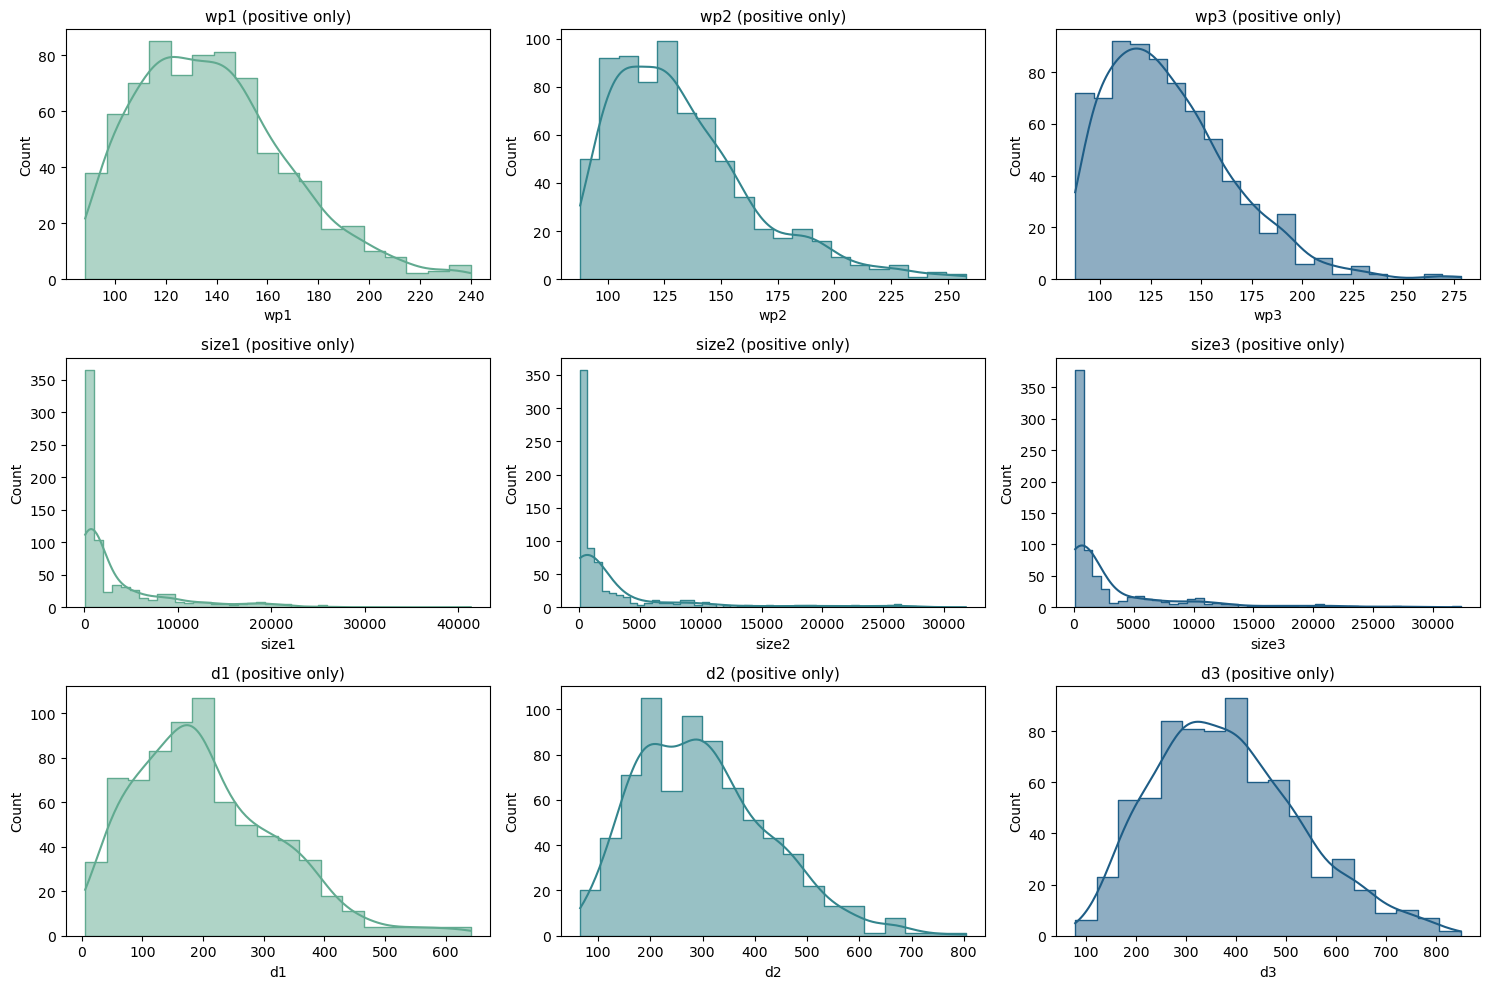

In [10]:
# Only positive cases with at least one valid storm
real_mask = ((df['mask1'] == 1) & (df['mask2'] == 1) & (df['mask3'] == 1)) & (df[f'Cb_dakar_t{lead_time}'] == 1)

features = ['wp', 'size', 'd']
storm_indices = [1, 2, 3]

# Use seaborn color palette
colors = sns.color_palette("crest", n_colors=3)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for row_idx, feature in enumerate(features):
    for col_idx, storm_idx in enumerate(storm_indices):
        ax = axes[row_idx, col_idx]
        feature_name = f'{feature}{storm_idx}'
        sns.histplot(
            data=df[real_mask], 
            x=feature_name, 
            kde=True, 
            ax=ax, 
            element="step", 
            fill=True,
            color=colors[col_idx]  # one colour per storm index
        )
        ax.set_title(f'{feature_name} (positive only)', fontsize=11)
        ax.set_xlabel(feature_name)
        ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


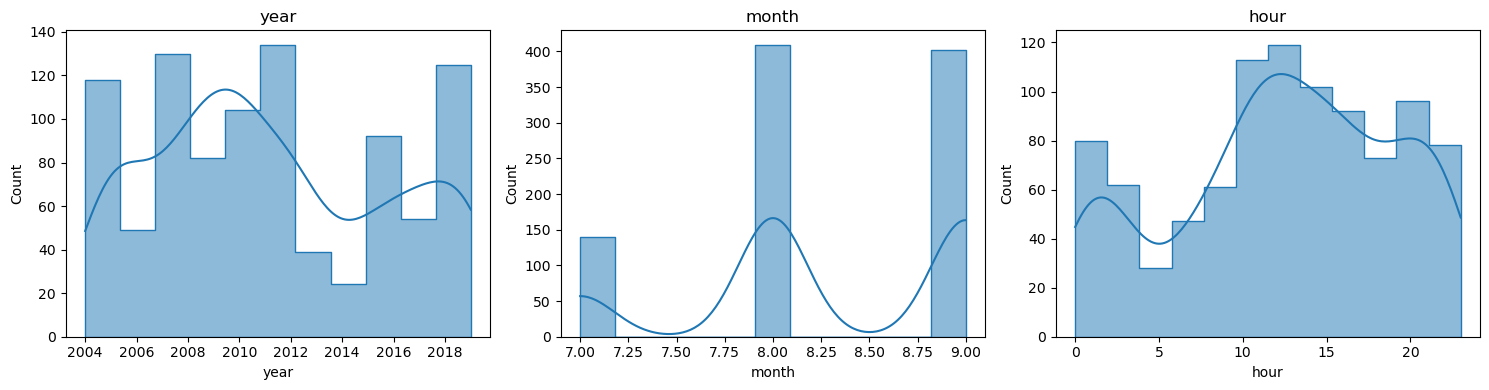

In [11]:
positive_df = df[df[f'Cb_dakar_t{lead_time}'] == 1]

time_features = ['year', 'month', 'hour']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
plt.subplots_adjust(wspace=0.4)

for idx, feature in enumerate(time_features):
    ax = axes[idx]
    sns.histplot(data=positive_df, x=feature, kde=True, ax=ax, element="step")
    ax.set_title(f'{feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Log transforming

In [12]:
for col in ['size1', 'size2', 'size3', 'wp1', 'wp2', 'wp3', 'd1', 'd2', 'd3']:
    X_train.loc[:, col] = np.log1p(X_train[col])
    X_val.loc[:, col] = np.log1p(X_val[col])
    X_test.loc[:, col] = np.log1p(X_test[col])

# Scaling

In [13]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2', 'mask3']

# Final list of features to scale
cols_to_scale = [col for col in X_train.columns 
                 if col not in mask_cols]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_val_scaled = X_val.copy()
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Model design

In [14]:
l1_reg = regularizers.L1(0.00001)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer=he_normal(), kernel_regularizer=l1_reg),
    tf.keras.layers.Dropout(0.4), 
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l1_reg),   
    tf.keras.layers.Dropout(0.4), 
    tf.keras.layers.Dense(8, activation='relu', kernel_regularizer=l1_reg),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

classification_threshold = 0.3

METRICS = [                      
    tf.keras.metrics.Recall(name='recall', thresholds=classification_threshold),
    tf.keras.metrics.Precision(name='precision', thresholds=classification_threshold),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.AUC(name='prc', curve='PR'), 
    tf.keras.metrics.F1Score(name='f1_score', threshold=classification_threshold),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=METRICS
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,721 (10.63 KB)

 Trainable params: 2,721 (10.63 KB)

 Non-trainable params: 0 (0.00 B)

# Model training

In [16]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

y_train = np.array(y_train).reshape(-1, 1)
y_val = np.array(y_val).reshape(-1, 1)


# train the model
model_history = model.fit(X_train_scaled, 
                          np.array(y_train), 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          #class_weight=class_weights,
                          validation_data=(X_val_scaled, np.array(y_val)),
                        )

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.4197 - f1_score: 0.0199 - loss: 0.7496 - prc: 0.0088 - precision: 0.0101 - recall: 0.7609 - val_auc: 0.3442 - val_f1_score: 0.0000e+00 - val_loss: 0.1019 - val_prc: 0.0072 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.4661 - f1_score: 0.0196 - loss: 0.1431 - prc: 0.0103 - precision: 0.0114 - recall: 0.0720 - val_auc: 0.6397 - val_f1_score: 0.0000e+00 - val_loss: 0.0633 - val_prc: 0.0163 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.5581 - f1_score: 0.0104 - loss: 0.0860 - prc: 0.0125 - precision: 0.0103 - recall: 0.0105 - val_auc: 0.7373 - val_f1_score: 0.0000e+00 - val_loss: 0.0602 - val_prc: 0.0262 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.6292 - f1_score: 0.0090 - loss: 0.0793 - prc: 0.0152 - precision: 0.0099 - recall: 0

# Model evaluation

In [17]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    """
    Computes the optimal classification threshold using Youden's J statistic (sensitivity + specificity - 1).

    Parameters:
        fpr (array-like): False positive rates.
        tpr (array-like): True positive rates.
        thresholds (array-like): Thresholds corresponding to fpr and tpr.

    Returns:
        float: Threshold that maximises Youden's J statistic.
    """
    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)
    thresholds = np.asarray(thresholds)

    j_scores = tpr - fpr
    max_index = np.argmax(j_scores)
    return thresholds[max_index]


def plot_cm(y_true, y_pred_proba, threshold=0.5, labels=None, normalize=False):
    """
    Plots a confusion matrix using seaborn heatmap.

    Parameters:
        y_true (array-like): Ground truth binary labels.
        y_pred_proba (array-like): Predicted probabilities.
        threshold (float): Classification threshold to convert probabilities to binary predictions.
        labels (list): Optional list of class labels (e.g. ['Negative', 'Positive']).
        normalize (bool): Whether to normalize the confusion matrix.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'g'

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues_r', linewidths=0.5,
                xticklabels=labels or ['No core', 'Core'],
                yticklabels=labels or ['No core', 'Core'])
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion Matrix (threshold = {threshold:.4f})')
    plt.tight_layout()
    plt.show()

702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step
Optimal threshold from validation: 0.018


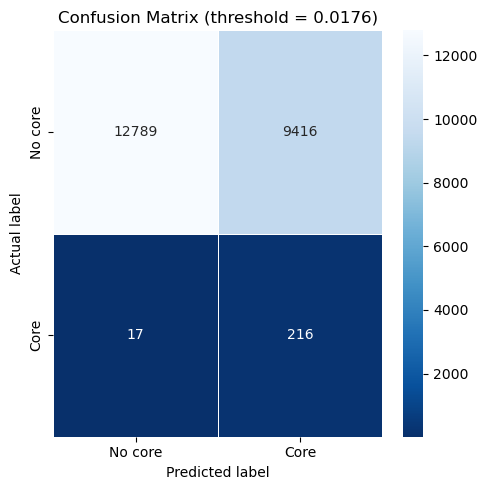

In [18]:
# Validation
y_val_pred = model.predict(X_val_scaled).flatten()
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
classification_threshold_val = cutoff_youdens_j(fpr, tpr, thresholds)
print(f"Optimal threshold from validation: {classification_threshold_val:.3f}")
plot_cm(y_val, y_val_pred, threshold=classification_threshold_val)


695/695 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step


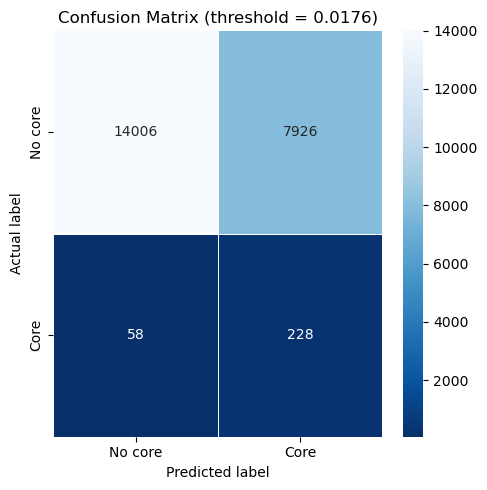

In [19]:
y_test_pred = model.predict(X_test_scaled).flatten()
plot_cm(y_test, y_test_pred, threshold=classification_threshold_val)

# In practical terms, reliability doesn’t matter much if you just want to trigger an alert when there's a 5% chance

In [20]:
def reliability_curve(y_true, y_pred, bin_size=0.1, min_predictions_per_bin=100):
    """
    Computes the reliability curve (calibration curve) for a binary classifier.
    
    Parameters:
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred (array-like): Predicted probabilities (between 0 and 1).
        bin_size (float): Width of the bins to divide probability space.
        min_predictions_per_bin (int): Minimum number of predictions in a bin to be included.
        
    Returns:
        bin_centers (list): Midpoints of the bins used.
        bin_positive_rates (list): Observed frequency of positive class in each bin.
        bin_counts (list): Number of predictions in each bin.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0, 1 + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_positive_rates = []
    bin_centers_output = []
    bin_counts = []

    for lower, upper, center in zip(bins[:-1], bins[1:], bin_centers):
        in_bin = (y_pred >= lower) & (y_pred < upper)
        count_in_bin = np.sum(in_bin)
        
        if count_in_bin >= min_predictions_per_bin:
            observed_rate = np.mean(y_true[in_bin])
            bin_positive_rates.append(round(observed_rate, 3))
            bin_centers_output.append(round(center, 3))
            bin_counts.append(count_in_bin)

    return bin_centers_output, bin_positive_rates, bin_counts

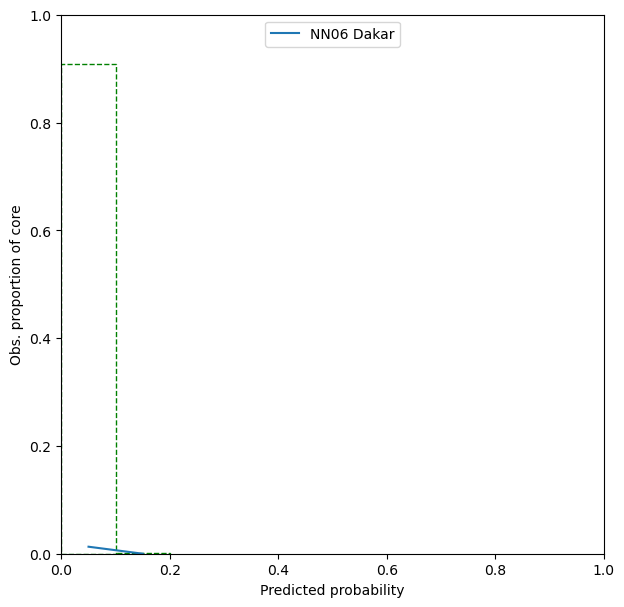

In [28]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_test_pred, min_predictions_per_bin=10)

plt.figure(figsize=(7,7))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of core")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
#plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)

plt.legend(loc='upper center')
plt.show()

In [22]:
y_train_pred = model.predict(X_train_scaled)
auc_train = roc_auc_score(y_train, y_train_pred)
auc_val   = roc_auc_score(y_val, y_val_pred)
auc_test  = roc_auc_score(y_test, y_test_pred)
auc_persistence = roc_auc_score(y_test, y_persistence)

2805/2805 ━━━━━━━━━━━━━━━━━━━━ 2s 761us/step


In [23]:
def plot_roc(name, y_true, y_pred_proba, **kwargs):
    """
    Plots the ROC curve with hit rate vs false alarm rate (% scale).
    
    Parameters:
        name (str): Label for the curve (e.g., model name).
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities (from model).
        **kwargs: Additional plotting keyword arguments (e.g. linestyle, color).
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    
    plt.plot(100 * fpr, 100 * tpr, label=name, linewidth=1.5, **kwargs)
    plt.xlabel('False Alarm Rate [%]')
    plt.ylabel('Hit Rate [%]')
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')

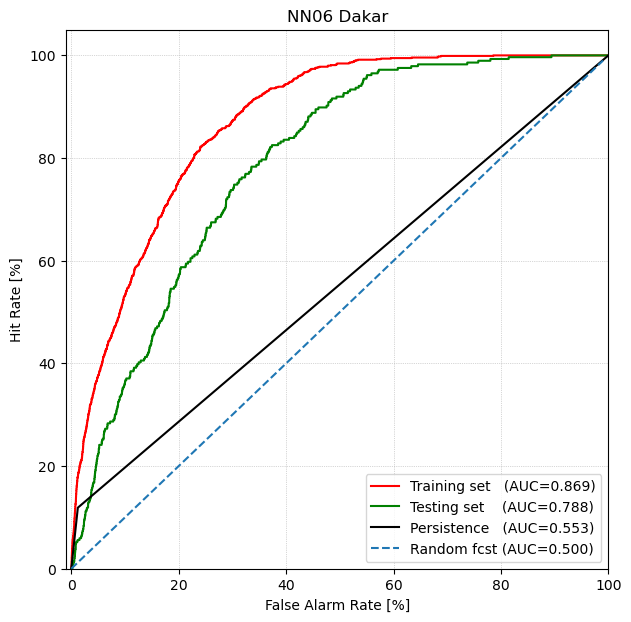

In [24]:
plt.figure(figsize=(7,7))
plot_roc(f"Training set   (AUC={auc_train:.3f})", y_train, y_train_pred, color="red")
plot_roc(f"Testing set    (AUC={auc_test:.3f})", y_test, y_test_pred, color='green')
plot_roc(f"Persistence   (AUC={auc_persistence:.3f})", y_test, y_persistence, color='black', linestyle='-')
plt.plot(range(0,100), range(0,100), label='Random fcst (AUC=0.500)', linestyle='--', linewidth=1.5)
plt.title(f"NN0{lead_time} Dakar")
plt.legend(loc='lower right');

# Saving the model

In [29]:
dump(scaler, f'./model-dakar-t{lead_time}.pkl')
model.save(f'./model-dakar-t{lead_time}.keras')